# EM1 Machine Learning Prediction Example

This notebook-style Python script shows a simple end-to-end machine learning
example for `EM1` using the workbook data already included in this project.

Goal:
- predict the next `CycleTime_sec` for `EM1`

Data used:
- `RawData`
- `SensorData`

Model used:
- `RandomForestRegressor`



In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


CURRENT_DIR = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR
WORKBOOK_PATH = PROJECT_ROOT / "AIM_MonitoringSystem.xlsx"
TARGET_MACHINE = "EM1"

print(f"Project root: {PROJECT_ROOT}")
print(f"Workbook path: {WORKBOOK_PATH}")




Project root: c:\Users\fairu\OneDrive - unimap.edu.my\Unimap\HP documents\Research\MOSTI\pprn\AIM
Workbook path: c:\Users\fairu\OneDrive - unimap.edu.my\Unimap\HP documents\Research\MOSTI\pprn\AIM\AIM_MonitoringSystem.xlsx


## 1. Load workbook data



In [2]:
raw_df = pd.read_excel(WORKBOOK_PATH, sheet_name="RawData")
sensor_df = pd.read_excel(WORKBOOK_PATH, sheet_name="SensorData")

raw_df["Timestamp"] = pd.to_datetime(raw_df["Timestamp"], errors="coerce")
sensor_df["Timestamp"] = pd.to_datetime(sensor_df["Timestamp"], errors="coerce")

raw_df = raw_df.dropna(subset=["Timestamp"]).sort_values("Timestamp").reset_index(drop=True)
sensor_df = sensor_df.dropna(subset=["Timestamp"]).sort_values("Timestamp").reset_index(drop=True)

print("RawData rows:", len(raw_df))
print("SensorData rows:", len(sensor_df))
raw_df.head()




RawData rows: 15645
SensorData rows: 63262


,Timestamp,Machine,Status,CycleTime_sec,AlarmCode,AlarmMessage,RejectCount,Notes
0,2026-05-07 14:15:31.257,EM1,idle,4.08,NaN,NaN,0.000000,NaN
1,2026-05-07 14:15:31.257,EM2,running,4.65,NaN,NaN,1.941721,NaN
2,2026-05-07 14:15:31.257,EM3,running,3.97,NaN,NaN,0.000000,NaN
3,2026-05-07 14:15:31.257,EM4,alarm,5.20,AL030,Final inspection reject rate high,9.000000,NaN
4,2026-05-07 14:20:31.257,EM1,running,3.82,NaN,NaN,0.000000,NaN


## 2. Filter data for EM1 only



In [3]:
raw_em1 = raw_df.loc[raw_df["Machine"] == TARGET_MACHINE].copy()
sensor_em1 = sensor_df.loc[sensor_df["Machine"] == TARGET_MACHINE].copy()

print("EM1 raw rows:", len(raw_em1))
print("EM1 sensor rows:", len(sensor_em1))
raw_em1.head()




EM1 raw rows: 3930
EM1 sensor rows: 18510


,Timestamp,Machine,Status,CycleTime_sec,AlarmCode,AlarmMessage,RejectCount,Notes
0,2026-05-07 14:15:31.257,EM1,idle,4.08,NaN,NaN,0.0,NaN
4,2026-05-07 14:20:31.257,EM1,running,3.82,NaN,NaN,0.0,NaN
8,2026-05-07 14:25:31.257,EM1,running,4.47,NaN,NaN,0.0,NaN
11,2026-05-07 14:30:31.257,EM1,alarm,5.80,AL002,Clamp pressure low,0.0,NaN
17,2026-05-07 14:35:31.257,EM1,running,4.01,NaN,NaN,0.0,NaN


## 3. Build sensor snapshot features

We pivot sensor readings so each EM1 sensor becomes one feature column.



In [4]:
sensor_snapshot = (
    sensor_em1.pivot_table(
        index="Timestamp",
        columns="SensorID",
        values="Value",
        aggfunc="last",
    )
    .sort_index()
    .reset_index()
)

sensor_snapshot.columns.name = None
sensor_snapshot.head()




,Timestamp,EM1_CURR_01,EM1_POSN_01,EM1_PRES_01,EM1_TEMP_01,EM1_TEMP_02
0,2026-05-07 14:20:31.257,6.74,0.22,4.21,207.05,210.36
1,2026-05-07 14:25:31.257,6.11,0.15,3.83,208.43,207.25
2,2026-05-07 14:30:31.257,6.56,0.28,2.10,214.02,202.39
3,2026-05-07 14:35:31.257,6.82,0.33,4.78,219.03,206.50
4,2026-05-07 14:38:35.022,6.30,0.24,4.27,214.73,201.37


## 4. Merge machine-level data with nearest sensor snapshot



In [5]:
raw_em1 = raw_em1.sort_values("Timestamp").reset_index(drop=True)
sensor_snapshot = sensor_snapshot.sort_values("Timestamp").reset_index(drop=True)

model_df = pd.merge_asof(
    raw_em1,
    sensor_snapshot,
    on="Timestamp",
    direction="backward",
)

print("Merged rows:", len(model_df))
model_df.head()




Merged rows: 3930


,Timestamp,Machine,Status,CycleTime_sec,AlarmCode,AlarmMessage,RejectCount,Notes,EM1_CURR_01,EM1_POSN_01,EM1_PRES_01,EM1_TEMP_01,EM1_TEMP_02
0,2026-05-07 14:15:31.257,EM1,idle,4.08,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-05-07 14:20:31.257,EM1,running,3.82,NaN,NaN,0.0,NaN,6.74,0.22,4.21,207.05,210.36
2,2026-05-07 14:25:31.257,EM1,running,4.47,NaN,NaN,0.0,NaN,6.11,0.15,3.83,208.43,207.25
3,2026-05-07 14:30:31.257,EM1,alarm,5.80,AL002,Clamp pressure low,0.0,NaN,6.56,0.28,2.10,214.02,202.39
4,2026-05-07 14:35:31.257,EM1,running,4.01,NaN,NaN,0.0,NaN,6.82,0.33,4.78,219.03,206.50


## 5. Create simple time-series features



In [6]:
model_df["CycleTime_lag1"] = model_df["CycleTime_sec"].shift(1)
model_df["CycleTime_lag2"] = model_df["CycleTime_sec"].shift(2)
model_df["CycleTime_roll3"] = model_df["CycleTime_sec"].rolling(window=3).mean()
model_df["RejectCount_lag1"] = model_df["RejectCount"].shift(1)
model_df["MinuteOfDay"] = model_df["Timestamp"].dt.hour * 60 + model_df["Timestamp"].dt.minute
model_df["Hour"] = model_df["Timestamp"].dt.hour

# Predict the next cycle time
model_df["Target_NextCycleTime"] = model_df["CycleTime_sec"].shift(-1)

model_df = model_df.dropna(subset=["Target_NextCycleTime"]).reset_index(drop=True)
model_df.head()




,Timestamp,Machine,Status,CycleTime_sec,AlarmCode,AlarmMessage,RejectCount,Notes,EM1_CURR_01,EM1_POSN_01,EM1_PRES_01,EM1_TEMP_01,EM1_TEMP_02,CycleTime_lag1,CycleTime_lag2,CycleTime_roll3,RejectCount_lag1,MinuteOfDay,Hour,Target_NextCycleTime
0,2026-05-07 14:15:31.257,EM1,idle,4.08,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,855,14,3.82
1,2026-05-07 14:20:31.257,EM1,running,3.82,NaN,NaN,0.0,NaN,6.74,0.22,4.21,207.05,210.36,4.08,NaN,NaN,0.0,860,14,4.47
2,2026-05-07 14:25:31.257,EM1,running,4.47,NaN,NaN,0.0,NaN,6.11,0.15,3.83,208.43,207.25,3.82,4.08,4.123333,0.0,865,14,5.80
3,2026-05-07 14:30:31.257,EM1,alarm,5.80,AL002,Clamp pressure low,0.0,NaN,6.56,0.28,2.10,214.02,202.39,4.47,3.82,4.696667,0.0,870,14,4.01
4,2026-05-07 14:35:31.257,EM1,running,4.01,NaN,NaN,0.0,NaN,6.82,0.33,4.78,219.03,206.50,5.80,4.47,4.760000,0.0,875,14,3.81


## 6. Choose features



In [7]:
sensor_feature_cols = [col for col in sensor_snapshot.columns if col != "Timestamp"]
base_feature_cols = [
    "CycleTime_sec",
    "CycleTime_lag1",
    "CycleTime_lag2",
    "CycleTime_roll3",
    "RejectCount",
    "RejectCount_lag1",
    "Hour",
    "MinuteOfDay",
]

feature_cols = [col for col in base_feature_cols + sensor_feature_cols if col in model_df.columns]
target_col = "Target_NextCycleTime"

dataset = model_df[["Timestamp"] + feature_cols + [target_col]].dropna(subset=[target_col]).copy()

print("Feature count:", len(feature_cols))
print("Dataset rows:", len(dataset))
feature_cols




Feature count: 13
Dataset rows: 3929


['CycleTime_sec',
 'CycleTime_lag1',
 'CycleTime_lag2',
 'CycleTime_roll3',
 'RejectCount',
 'RejectCount_lag1',
 'Hour',
 'MinuteOfDay',
 'EM1_CURR_01',
 'EM1_POSN_01',
 'EM1_PRES_01',
 'EM1_TEMP_01',
 'EM1_TEMP_02']

## 7. Train/test split by time



In [8]:
split_index = int(len(dataset) * 0.8)
train_df = dataset.iloc[:split_index].copy()
test_df = dataset.iloc[split_index:].copy()

X_train = train_df[feature_cols]
y_train = train_df[target_col]
X_test = test_df[feature_cols]
y_test = test_df[target_col]

print("Train rows:", len(train_df))
print("Test rows:", len(test_df))




Train rows: 3143
Test rows: 786


## 8. Train a simple regression pipeline



In [9]:
numeric_features = feature_cols

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            numeric_features,
        )
    ]
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "regressor",
            RandomForestRegressor(
                n_estimators=200,
                max_depth=8,
                min_samples_leaf=3,
                random_state=42,
            ),
        ),
    ]
)

model.fit(X_train, y_train)
pred_test = model.predict(X_test)

mae = mean_absolute_error(y_test, pred_test)
r2 = r2_score(y_test, pred_test)

print(f"EM1 next-cycle-time MAE: {mae:.4f}")
print(f"EM1 next-cycle-time R^2: {r2:.4f}")




EM1 next-cycle-time MAE: 0.4673
EM1 next-cycle-time R^2: -0.0061


## 9. Visualize actual vs predicted cycle time



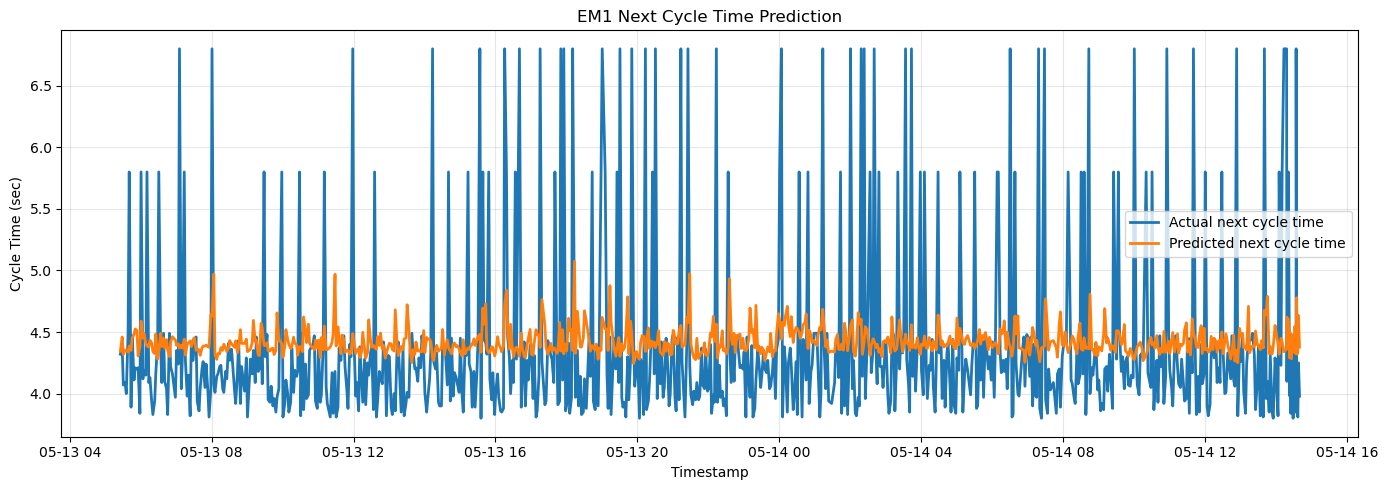

In [10]:
results_df = pd.DataFrame(
    {
        "Timestamp": test_df["Timestamp"],
        "Actual": y_test,
        "Predicted": pred_test,
    }
)

plt.figure(figsize=(14, 5))
plt.plot(results_df["Timestamp"], results_df["Actual"], label="Actual next cycle time", linewidth=2)
plt.plot(results_df["Timestamp"], results_df["Predicted"], label="Predicted next cycle time", linewidth=2)
plt.title("EM1 Next Cycle Time Prediction")
plt.xlabel("Timestamp")
plt.ylabel("Cycle Time (sec)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()




## 10. Feature importance



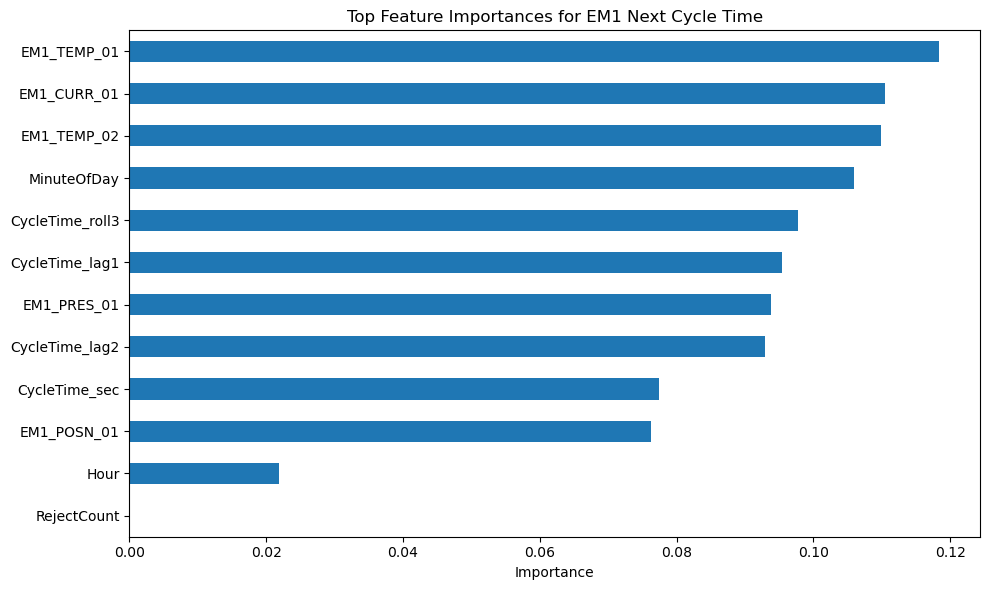

EM1_TEMP_01        0.118426
EM1_CURR_01        0.110409
EM1_TEMP_02        0.109824
MinuteOfDay        0.105995
CycleTime_roll3    0.097721
CycleTime_lag1     0.095443
EM1_PRES_01        0.093824
CycleTime_lag2     0.092858
CycleTime_sec      0.077365
EM1_POSN_01        0.076240
Hour               0.021896
RejectCount        0.000000
dtype: float64

In [11]:
rf_model = model.named_steps["regressor"]
importances = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=False)

top_n = 12
plt.figure(figsize=(10, 6))
importances.head(top_n).sort_values().plot(kind="barh")
plt.title("Top Feature Importances for EM1 Next Cycle Time")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

importances.head(top_n)




## 11. Simple example prediction row



In [12]:
latest_row = dataset.iloc[[-1]][feature_cols]
next_cycle_prediction = model.predict(latest_row)[0]

print("Latest EM1 feature row timestamp:", dataset.iloc[-1]["Timestamp"])
print(f"Predicted next cycle time for EM1: {next_cycle_prediction:.4f} sec")




Latest EM1 feature row timestamp: 2026-05-14 14:39:55.770000
Predicted next cycle time for EM1: 4.3780 sec


## Notes

This is intentionally a simple example for GitHub and experimentation.
Good next steps would be:
- classify whether `EM1` will enter `alarm` soon
- predict anomaly risk instead of only cycle time
- use longer lag windows and rolling statistics
- train on all machines with machine ID as a feature
- export the fitted model for later inference
